In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from collections import Counter

In [ ]:

# Upload data.csv

uploaded = files.upload()
df = pd.read_csv("data.csv")

print("Dataset shape:", df.shape)
display(df.head())

Saving data.csv to data (1).csv
Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:

# Select features and target

features = [
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave points_worst", "symmetry_worst", "fractal_dimension_worst"
]

X = df[features].copy()
y = df["diagnosis"].map({"M": 1, "B": 0})

print("Number of samples:", len(X))
print("Number of features:", X.shape[1])
print("\nClass distribution:")
print(df["diagnosis"].value_counts())


Number of samples: 569
Number of features: 30

Class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
# Convert features to numbers and handle missing values

X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

X = X.values
y = y.values

In [ ]:

# 80% training and 20% testing

np.random.seed(42)

indices = np.arange(len(X))
np.random.shuffle(indices)

split = int(0.8 * len(X))

train_idx = indices[:split]
test_idx = indices[split:]

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


Training data: (455, 30)
Testing data : (114, 30)


In [ ]:

# Standardize the features

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

std[std == 0] = 1

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std


In [ ]:
# Distance functions

def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def manhattan(a, b):
    return np.sum(np.abs(a - b))


def minkowski(a, b, p=3):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)


def cosine(a, b):
    denominator = np.linalg.norm(a) * np.linalg.norm(b)

    if denominator == 0:
        return 1

    return 1 - (np.dot(a, b) / denominator)


def hamming(a, b):
    return np.mean(a != b)


In [ ]:

# Convert data to binary for Hamming distance

median = np.median(X_train, axis=0)

X_train_hamming = (X_train >= median).astype(int)
X_test_hamming = (X_test >= median).astype(int)


In [ ]:

# KNN from scratch

def knn_predict(X_train, y_train, X_test, k, distance, hamming_mode=False):

    predictions = []

    for test_point in X_test:

        distances = []

        for i in range(len(X_train)):
            d = distance(test_point, X_train[i])
            distances.append((d, y_train[i]))

        distances.sort(key=lambda x: x[0])

        neighbors = distances[:k]

        labels = [label for distance_value, label in neighbors]

        prediction = Counter(labels).most_common(1)[0][0]

        predictions.append(prediction)

    return np.array(predictions)


In [ ]:

# Accuracy function

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [ ]:

# Experiment with different K values and distances

k_values = [3, 4, 9, 20, 47]

distances = {
    "Euclidean": euclidean,
    "Manhattan": manhattan,
    "Minkowski": minkowski,
    "Cosine": cosine
}

results = []

for name, distance in distances.items():

    for k in k_values:

        prediction = knn_predict(
            X_train,
            y_train,
            X_test,
            k,
            distance
        )

        acc = accuracy(y_test, prediction)

        results.append([name, k, acc])


# Hamming separately because it uses binary data

for k in k_values:

    prediction = knn_predict(
        X_train_hamming,
        y_train,
        X_test_hamming,
        k,
        hamming
    )

    acc = accuracy(y_test, prediction)

    results.append(["Hamming", k, acc])


results = pd.DataFrame(
    results,
    columns=["Distance", "K", "Accuracy"]
)

display(results)


,Distance,K,Accuracy
0,Euclidean,3,0.947368
1,Euclidean,4,0.956140
2,Euclidean,9,0.929825
3,Euclidean,20,0.938596
4,Euclidean,47,0.938596
5,Manhattan,3,0.964912
6,Manhattan,4,0.964912
7,Manhattan,9,0.947368
8,Manhattan,20,0.938596
9,Manhattan,47,0.938596


In [ ]:

# Find the best K and distance

best = results.loc[results["Accuracy"].idxmax()]

best_distance = best["Distance"]
best_k = int(best["K"])

print("Best Distance:", best_distance)
print("Best K:", best_k)
print("Best Accuracy:", round(best["Accuracy"] * 100, 2), "%")


Best Distance: Manhattan
Best K: 3
Best Accuracy: 96.49 %


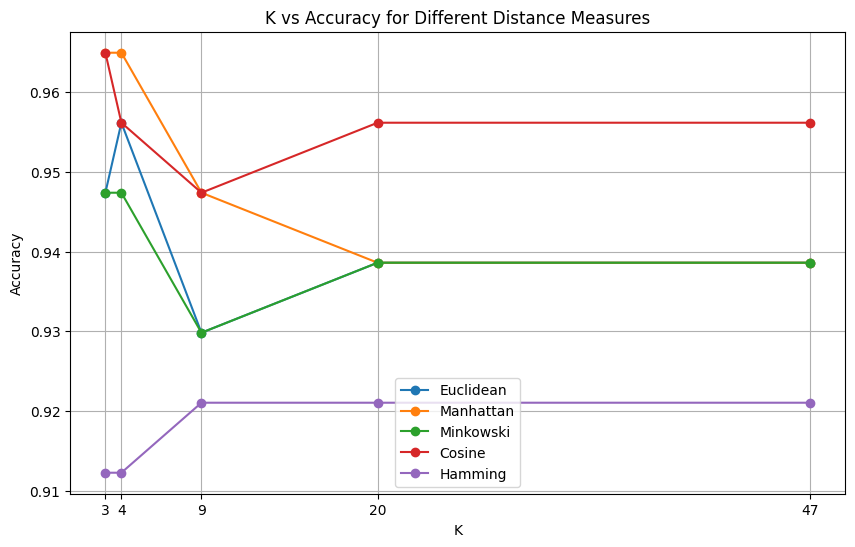

In [ ]:

# Plot K vs Accuracy

plt.figure(figsize=(10, 6))

for name in results["Distance"].unique():

    data = results[results["Distance"] == name]

    plt.plot(
        data["K"],
        data["Accuracy"],
        marker="o",
        label=name
    )

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy for Different Distance Measures")
plt.xticks(k_values)
plt.grid()
plt.legend()
plt.show()


In [ ]:

# Prediction using the best model

if best_distance == "Hamming":

    best_prediction = knn_predict(
        X_train_hamming,
        y_train,
        X_test_hamming,
        best_k,
        hamming
    )

else:

    best_prediction = knn_predict(
        X_train,
        y_train,
        X_test,
        best_k,
        distances[best_distance]
    )

print("Accuracy:", round(accuracy(y_test, best_prediction) * 100, 2), "%")


Accuracy: 96.49 %


In [ ]:

# Confusion Matrix

def confusion_matrix(y_true, y_pred):

    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    return np.array([
        [tn, fp],
        [fn, tp]
    ])


cm = confusion_matrix(y_test, best_prediction)

print("Confusion Matrix:")
print(cm)

print("\n              Predicted")
print("              B     M")
print("Actual B     ", cm[0][0], " ", cm[0][1])
print("Actual M     ", cm[1][0], " ", cm[1][1])


Confusion Matrix:
[[67  0]
 [ 4 43]]

              Predicted
              B     M
Actual B      67   0
Actual M      4   43


In [ ]:

# Precision and Recall

tn, fp = cm[0]
fn, tp = cm[1]

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0

print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))


Precision: 1.0
Recall   : 0.9149


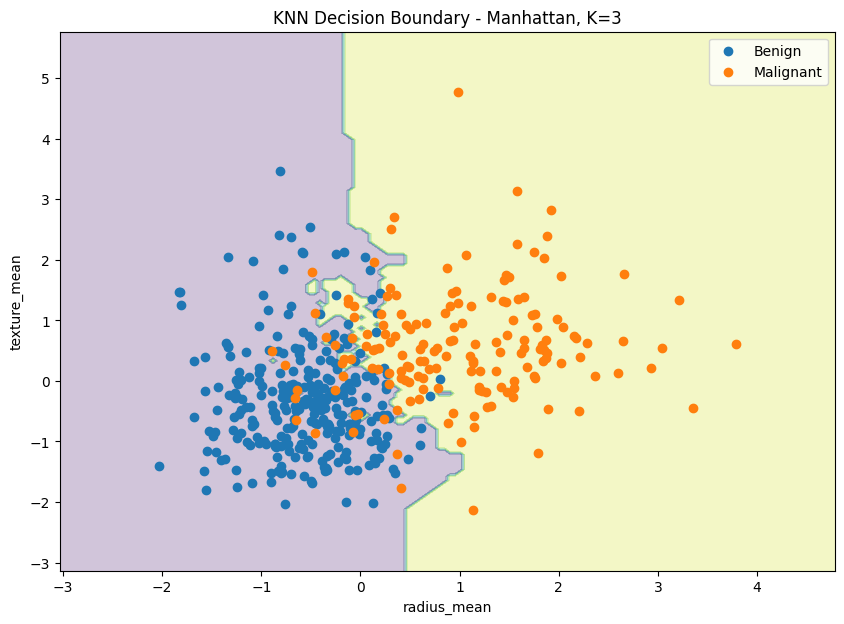

In [ ]:

# Bonus: 2D decision boundary

X2 = X[:, :2]

# Split using the same indices
X2_train = X2[train_idx]
X2_test = X2[test_idx]

# Standardize using training data
mean2 = X2_train.mean(axis=0)
std2 = X2_train.std(axis=0)
std2[std2 == 0] = 1

X2_train = (X2_train - mean2) / std2
X2_test = (X2_test - mean2) / std2


# Use the best distance and K
if best_distance == "Hamming":

    median2 = np.median(X2_train, axis=0)

    X2_train_h = (X2_train >= median2).astype(int)

    def predict_point(point):

        point_h = (point >= median2).astype(int)

        return knn_predict(
            X2_train_h,
            y_train,
            np.array([point_h]),
            best_k,
            hamming
        )[0]

else:

    def predict_point(point):

        return knn_predict(
            X2_train,
            y_train,
            np.array([point]),
            best_k,
            distances[best_distance]
        )[0]


# Create grid
x_min = X2_train[:, 0].min() - 1
x_max = X2_train[:, 0].max() + 1

y_min = X2_train[:, 1].min() - 1
y_max = X2_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 150),
    np.linspace(y_min, y_max, 150)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = []

for point in grid:
    Z.append(predict_point(point))

Z = np.array(Z).reshape(xx.shape)


# Plot
plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.25)

plt.scatter(
    X2_train[y_train == 0, 0],
    X2_train[y_train == 0, 1],
    label="Benign"
)

plt.scatter(
    X2_train[y_train == 1, 0],
    X2_train[y_train == 1, 1],
    label="Malignant"
)

plt.xlabel("radius_mean")
plt.ylabel("texture_mean")

plt.title(
    "KNN Decision Boundary - "
    + best_distance
    + ", K="
    + str(best_k)
)

plt.legend()
plt.show()
